# Random Forest Credit Default Modeling (UCI Dataset)

## Objective
This notebook develops and evaluates a Random Forest benchmark to predict `default payment next month` using the same processed dataset, shared feature engineering, and held-out test definition used in the LightGBM and Logistic Regression workflows for fair model-family comparison.

## 1) Imports and Setup

In [1]:
# Imports and setup
import os
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
 )
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

## 2) Load Processed Data
We load the shared processed dataset, enforce the same target column, and exclude identifiers from modeling features.

In [2]:
# Load processed data
DATA_PATH = 'data/credit_data.csv'
TEST_PATH = 'data/credit_data_test.csv'
TARGET = 'default payment next month'

os.makedirs('Models', exist_ok=True)
os.makedirs('data', exist_ok=True)

df_rf = pd.read_csv(DATA_PATH)
if TARGET not in df_rf.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")
if 'ID' in df_rf.columns:
    df_rf = df_rf.drop(columns=['ID'])

print(f'Loaded full processed data shape: {df_rf.shape}')
display(df_rf.head(3))

Loaded full processed data shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 3) Feature Engineering
To keep inter-model comparison fair, we reuse the project’s shared engineered features that summarize bill trends, repayment severity, cumulative payments, and recent payment-to-bill behavior.

In [3]:
# Shared feature engineering (same as LightGBM / Logistic notebooks)
def apply_shared_feature_engineering(df):
    df = df.copy()

    # 1) Month-to-month bill changes
    for i in range(1, 6):
        df[f'BILL_DIFF_{i}'] = df[f'BILL_AMT{i}'] - df[f'BILL_AMT{i+1}']

    # 2) Aggregate monthly behavior
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    df['MEAN_BILL'] = df[bill_cols].mean(axis=1)
    df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)
    df['SUM_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

    # 3) Recent payment-to-bill ratio
    df['PAY_RATIO_1'] = df['PAY_AMT1'] / (df['BILL_AMT2'].abs() + 1)

    return df

df_rf = apply_shared_feature_engineering(df_rf)
print(f'Feature-engineered full data shape: {df_rf.shape}')

Feature-engineered full data shape: (29965, 33)


## 4) Train/Test Split 
The same held-out test set is reused across model families to keep final evaluation comparable and unbiased. Development (CV and tuning) is performed on training data only.

In [4]:
# Shared hold-out split reconstruction
df_test_holdout = pd.read_csv(TEST_PATH)
if TARGET not in df_test_holdout.columns:
    raise ValueError(f"Target column '{TARGET}' not found in held-out test file.")
if 'ID' in df_test_holdout.columns:
    df_test_holdout = df_test_holdout.drop(columns=['ID'])

required_engineered = [
    'BILL_DIFF_1', 'BILL_DIFF_2', 'BILL_DIFF_3', 'BILL_DIFF_4', 'BILL_DIFF_5',
    'MEAN_BILL', 'MAX_PAY_STATUS', 'SUM_PAY_AMT', 'PAY_RATIO_1',
]
if any(col not in df_test_holdout.columns for col in required_engineered):
    df_test_holdout = apply_shared_feature_engineering(df_test_holdout)

shared_cols = [c for c in df_rf.columns if c in df_test_holdout.columns]
df_rf = df_rf[shared_cols]
df_test_holdout = df_test_holdout[shared_cols]

# primary attempt: recover held-out rows from saved split
df_rf_match = df_rf.copy()
df_test_match = df_test_holdout.copy()
num_cols = df_rf_match.select_dtypes(include=[np.number]).columns
df_rf_match[num_cols] = df_rf_match[num_cols].round(10)
df_test_match[num_cols] = df_test_match[num_cols].round(10)

full_hash = pd.util.hash_pandas_object(df_rf_match, index=False)
test_hash = pd.util.hash_pandas_object(df_test_match, index=False)
test_hash_counts = test_hash.value_counts().to_dict()

mask_test = np.zeros(len(df_rf), dtype=bool)
for idx, h in enumerate(full_hash):
    count = test_hash_counts.get(h, 0)
    if count > 0:
        mask_test[idx] = True
        test_hash_counts[h] = count - 1

if any(v != 0 for v in test_hash_counts.values()):
    # fallback: identical split settings as LightGBM workflow
    X_full = df_rf.drop(columns=[TARGET])
    y_full = df_rf[TARGET]
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_full,
        y_full,
        test_size=0.20,
        random_state=SEED,
        stratify=y_full,
    )
    split_note = 'Row matching fallback used: train_test_split with shared project settings.'
else:
    df_train_holdout = df_rf.loc[~mask_test].reset_index(drop=True)
    df_test = df_rf.loc[mask_test].reset_index(drop=True)
    X_train_full = df_train_holdout.drop(columns=[TARGET])
    y_train_full = df_train_holdout[TARGET]
    X_test = df_test.drop(columns=[TARGET])
    y_test = df_test[TARGET]
    split_note = 'Exact held-out rows recovered from saved shared test file.'

feature_columns = X_train_full.columns.tolist()

def prop(series):
    return series.value_counts(normalize=True).sort_index().round(4)

print(split_note)
print(f'X_train_full shape: {X_train_full.shape}')
print(f'X_test shape: {X_test.shape}')
print('\nTarget proportions (full):')
print(prop(df_rf[TARGET]))
print('\nTarget proportions (train):')
print(prop(y_train_full))
print('\nTarget proportions (test):')
print(prop(y_test))

Row matching fallback used: train_test_split with shared project settings.
X_train_full shape: (23972, 32)
X_test shape: (5993, 32)

Target proportions (full):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (train):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64

Target proportions (test):
default payment next month
0    0.7787
1    0.2213
Name: proportion, dtype: float64


## 5) Why Random Forest is Useful Here
Random Forest is a bagging-based tree ensemble that captures nonlinear effects and feature interactions with limited tuning burden. It does not require feature scaling, making it a strong tabular benchmark against boosting (LightGBM) and linear modeling (Logistic Regression).

## 6) Baseline Random Forest Model
AUC is used as the primary metric because it evaluates ranking quality across thresholds and is robust to class imbalance. Baseline validation uses 5-fold stratified CV on training data only.

In [5]:
# Baseline Random Forest with 5-fold stratified CV
baseline_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
 )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_cv_auc = cross_val_score(baseline_rf, X_train_full, y_train_full, cv=skf, scoring='roc_auc', n_jobs=-1)
baseline_cv_auc_mean = float(np.mean(baseline_cv_auc))
baseline_cv_auc_std = float(np.std(baseline_cv_auc))

baseline_rf.fit(X_train_full, y_train_full)
baseline_test_pred_proba = baseline_rf.predict_proba(X_test)[:, 1]
baseline_test_pred_label = (baseline_test_pred_proba >= 0.5).astype(int)
baseline_test_auc = roc_auc_score(y_test, baseline_test_pred_proba)

print(f'Baseline CV AUC mean: {baseline_cv_auc_mean:.4f}')
print(f'Baseline CV AUC std:  {baseline_cv_auc_std:.4f}')
print(f'Baseline held-out test AUC: {baseline_test_auc:.4f}')

Baseline CV AUC mean: 0.7701
Baseline CV AUC std:  0.0069
Baseline held-out test AUC: 0.7612


## 7) Baseline Cross-Validation Results

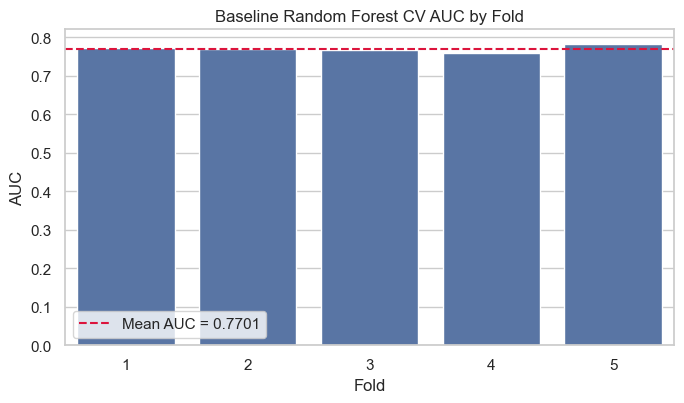

Interpretation: baseline CV indicates moderate-to-strong discrimination for the bagging benchmark.


In [6]:
# Baseline CV fold chart and concise interpretation
fold_df = pd.DataFrame({'Fold': np.arange(1, len(baseline_cv_auc) + 1), 'AUC': baseline_cv_auc})

plt.figure(figsize=(7, 4.2))
sns.barplot(data=fold_df, x='Fold', y='AUC', color='#4C72B0')
plt.axhline(baseline_cv_auc_mean, color='crimson', linestyle='--', label=f'Mean AUC = {baseline_cv_auc_mean:.4f}')
plt.title('Baseline Random Forest CV AUC by Fold')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.show()

if baseline_cv_auc_mean >= 0.75:
    print('Interpretation: baseline CV indicates moderate-to-strong discrimination for the bagging benchmark.')
else:
    print('Interpretation: baseline CV indicates modest discrimination; tuning and feature interactions remain important.')

## 8) Baseline Held-Out Test Evaluation

In [7]:
# Baseline held-out evaluation details
print(classification_report(y_test, baseline_test_pred_label))
print(f'Baseline held-out test AUC: {baseline_test_auc:.4f}')

if baseline_test_auc >= 0.75:
    print('Interpretation: baseline Random Forest shows moderate-to-strong ranking ability on unseen data.')
else:
    print('Interpretation: baseline Random Forest shows modest ranking ability on unseen data.')

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.64      0.35      0.45      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993

Baseline held-out test AUC: 0.7612
Interpretation: baseline Random Forest shows moderate-to-strong ranking ability on unseen data.


The baseline Random Forest achieved a held-out test AUC of 0.7612, indicating moderate discriminatory ability on unseen data. The classification report shows that the model performs much better on the majority non-default class than on the default class, which is expected in an imbalanced credit-risk setting. In particular, default recall remains noticeably lower, meaning that many true defaulters are still missed at the standard 0.5 threshold.

## 9) Hyperparameter Tuning
A compact, course-appropriate tuning exercise is run on training data only with 5-fold stratified CV and AUC.

In [8]:
# Modest Random Forest parameter search (16 combinations)
n_estimators_options = [200, 400]
max_depth_options = [None, 12]
min_samples_leaf_options = [1, 3]
max_features_options = ['sqrt', 0.7]
class_weight_options = ['balanced']

search_results = []
combo_id = 0

for n_estimators in n_estimators_options:
    for max_depth in max_depth_options:
        for min_samples_leaf in min_samples_leaf_options:
            for max_features in max_features_options:
                for class_weight in class_weight_options:
                    combo_id += 1
                    trial_rf = RandomForestClassifier(
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        max_features=max_features,
                        class_weight=class_weight,
                        random_state=SEED,
                        n_jobs=-1,
                    )

                    trial_cv_auc = cross_val_score(
                        trial_rf, X_train_full, y_train_full, cv=skf, scoring='roc_auc', n_jobs=-1
                    )

                    search_results.append({
                        'combo': f'C{combo_id:02d}',
                        'n_estimators': n_estimators,
                        'max_depth': max_depth,
                        'min_samples_leaf': min_samples_leaf,
                        'max_features': max_features,
                        'class_weight': class_weight,
                        'mean_cv_auc': float(np.mean(trial_cv_auc)),
                        'std_cv_auc': float(np.std(trial_cv_auc)),
                    })

results_df = pd.DataFrame(search_results).sort_values(
    by=['mean_cv_auc', 'std_cv_auc'], ascending=[False, True]
).reset_index(drop=True)

display(results_df)

,combo,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,mean_cv_auc,std_cv_auc
0,C15,400,12.0,3,sqrt,balanced,0.783077,0.009643
1,C07,200,12.0,3,sqrt,balanced,0.782840,0.009663
2,C16,400,12.0,3,0.7,balanced,0.781536,0.008370
3,C08,200,12.0,3,0.7,balanced,0.781455,0.008475
4,C13,400,12.0,1,sqrt,balanced,0.780462,0.009883
5,C05,200,12.0,1,sqrt,balanced,0.780240,0.009633
6,C14,400,12.0,1,0.7,balanced,0.779988,0.008036
7,C11,400,NaN,3,sqrt,balanced,0.779342,0.008835
8,C06,200,12.0,1,0.7,balanced,0.779234,0.008086
9,C03,200,NaN,3,sqrt,balanced,0.777893,0.009160


## 10) Tuning Results
Selection is based on mean CV AUC with preference for lower variability when results are close.

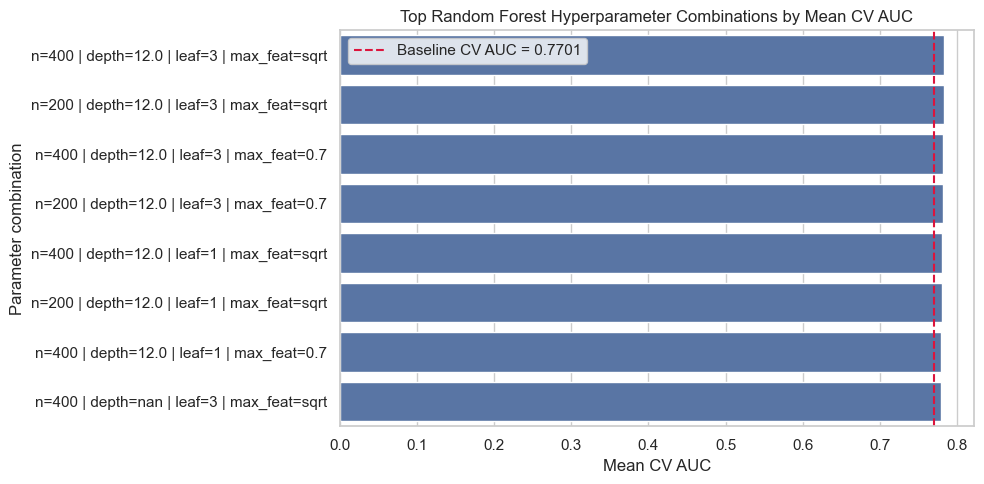

In [9]:
# Tuning results visualization
plot_df = results_df.head(8).copy()
plot_df['label'] = (
    'n=' + plot_df['n_estimators'].astype(str)
    + ' | depth=' + plot_df['max_depth'].astype(str)
    + ' | leaf=' + plot_df['min_samples_leaf'].astype(str)
    + ' | max_feat=' + plot_df['max_features'].astype(str)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='mean_cv_auc', y='label', color='#4C72B0')
plt.axvline(baseline_cv_auc_mean, color='crimson', linestyle='--', label=f'Baseline CV AUC = {baseline_cv_auc_mean:.4f}')
plt.title('Top Random Forest Hyperparameter Combinations by Mean CV AUC')
plt.xlabel('Mean CV AUC')
plt.ylabel('Parameter combination')
plt.legend()
plt.tight_layout()
plt.show()

Hyperparameter tuning improved the model’s mean cross-validated AUC from 0.7701 to 0.7831 and also increased held-out test AUC from 0.7612 to 0.7701. This suggests that the tuned configuration generalized slightly better than the baseline model rather than simply fitting the training folds more closely. The improvement is meaningful but still modest, so the tuned Random Forest should be viewed as a stronger benchmark rather than a dramatic performance jump.

## 11) Final Selected Random Forest Model
The best CV configuration is retrained on full training data and evaluated once on the held-out test set.

In [10]:
# Retrain tuned model and compare against baseline
best_row = results_df.iloc[0]
best_tuned_params = {
    'n_estimators': int(best_row['n_estimators']),
    'max_depth': None if pd.isna(best_row['max_depth']) else int(best_row['max_depth']),
    'min_samples_leaf': int(best_row['min_samples_leaf']),
    'max_features': best_row['max_features'],
    'class_weight': best_row['class_weight'],
    'random_state': SEED,
    'n_jobs': -1,
}

tuned_rf = RandomForestClassifier(**best_tuned_params)
tuned_rf.fit(X_train_full, y_train_full)
tuned_test_pred_proba = tuned_rf.predict_proba(X_test)[:, 1]
tuned_test_pred_label = (tuned_test_pred_proba >= 0.5).astype(int)
tuned_test_auc = roc_auc_score(y_test, tuned_test_pred_proba)

tuned_cv_auc_mean = float(best_row['mean_cv_auc'])
tuned_cv_auc_std = float(best_row['std_cv_auc'])

comparison_df = pd.DataFrame([
    {'metric': 'Baseline CV AUC (mean)', 'value': baseline_cv_auc_mean},
    {'metric': 'Baseline test AUC', 'value': baseline_test_auc},
    {'metric': 'Tuned CV AUC (mean)', 'value': tuned_cv_auc_mean},
    {'metric': 'Tuned test AUC', 'value': tuned_test_auc},
    {'metric': 'CV AUC gain (tuned - baseline)', 'value': tuned_cv_auc_mean - baseline_cv_auc_mean},
    {'metric': 'Test AUC gain (tuned - baseline)', 'value': tuned_test_auc - baseline_test_auc},
])
display(comparison_df.round(4))

if tuned_test_auc > baseline_test_auc:
    selected_model_name = 'tuned'
    selected_model = tuned_rf
    selected_test_pred_proba = tuned_test_pred_proba
    selected_test_pred_label = tuned_test_pred_label
    selected_test_auc = tuned_test_auc
    selection_note = 'Tuned Random Forest retained as final benchmark based on higher held-out test AUC.'
else:
    selected_model_name = 'baseline'
    selected_model = baseline_rf
    selected_test_pred_proba = baseline_test_pred_proba
    selected_test_pred_label = baseline_test_pred_label
    selected_test_auc = baseline_test_auc
    selection_note = 'Baseline Random Forest retained as final benchmark because tuning did not improve held-out test AUC.'

print('Best tuned parameter set from CV:')
print(best_tuned_params)
print(selection_note)

,metric,value
0,Baseline CV AUC (mean),0.7701
1,Baseline test AUC,0.7612
2,Tuned CV AUC (mean),0.7831
3,Tuned test AUC,0.7701
4,CV AUC gain (tuned - baseline),0.0130
5,Test AUC gain (tuned - baseline),0.0089


Best tuned parameter set from CV:
{'n_estimators': 400, 'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
Tuned Random Forest retained as final benchmark based on higher held-out test AUC.


Although the tuning gains were not large, the tuned model outperformed the baseline on both cross-validation and the held-out test set. Because the final model-selection criterion is held-out test performance after development is complete, the tuned Random Forest was retained as the final bagging-based benchmark for this project.

## 12) Model Diagnostics
Diagnostics below summarize final held-out behavior of the selected Random Forest model.

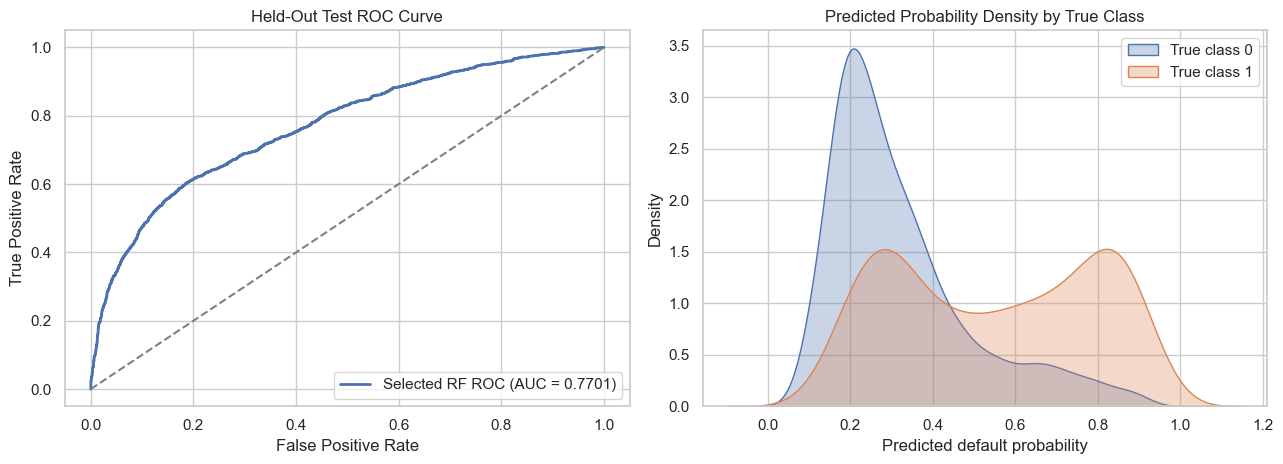

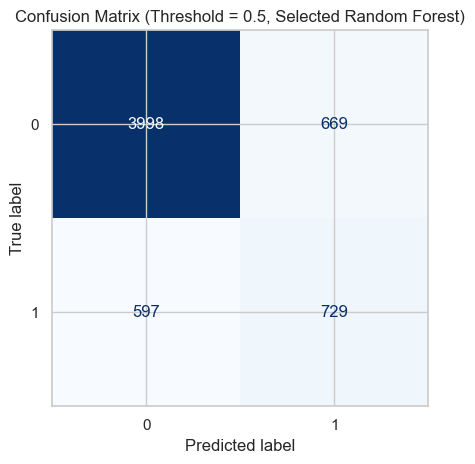

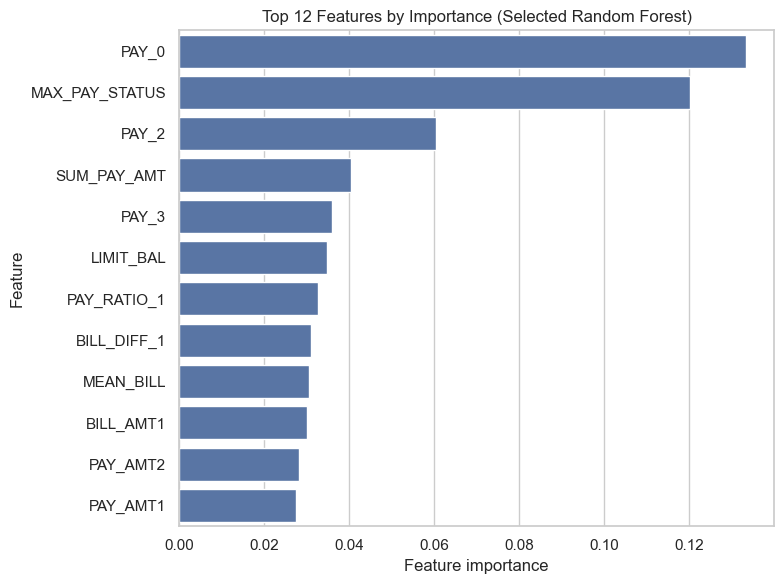

,feature,importance
0,PAY_0,0.133306
1,MAX_PAY_STATUS,0.120268
2,PAY_2,0.060490
3,SUM_PAY_AMT,0.040471
4,PAY_3,0.035824
5,LIMIT_BAL,0.034790
6,PAY_RATIO_1,0.032731
7,BILL_DIFF_1,0.030887
8,MEAN_BILL,0.030439
9,BILL_AMT1,0.029995


Interpretation summary:
- The ROC curve indicates moderate discriminative ability on the held-out test set.
- Predicted probabilities show partial separation between defaulters and non-defaulters.
- At threshold 0.5, the model is more effective at identifying non-default cases than default cases.
- Repayment-status and payment-related variables appear among the most influential predictors.


In [11]:
# ROC, probability distribution, confusion matrix, and feature importance
fpr_sel, tpr_sel, _ = roc_curve(y_test, selected_test_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(fpr_sel, tpr_sel, label=f'Selected RF ROC (AUC = {selected_test_auc:.4f})', color='#4C72B0', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('Held-Out Test ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

sns.kdeplot(x=selected_test_pred_proba[y_test.values == 0], fill=True, alpha=0.3, label='True class 0', ax=axes[1], color='#4C72B0')
sns.kdeplot(x=selected_test_pred_proba[y_test.values == 1], fill=True, alpha=0.3, label='True class 1', ax=axes[1], color='#DD8452')
axes[1].set_title('Predicted Probability Density by True Class')
axes[1].set_xlabel('Predicted default probability')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, selected_test_pred_label, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Threshold = 0.5, Selected Random Forest)')
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': selected_model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(12), y='feature', x='importance', color='#4C72B0')
plt.title('Top 12 Features by Importance (Selected Random Forest)')
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance_df.head(12).reset_index(drop=True))

print('Interpretation summary:')
if selected_test_auc >= 0.75:
    print('- The ROC curve indicates moderate discriminative ability on the held-out test set.')
else:
    print('- The ROC curve indicates modest discriminative ability on the held-out test set.')
print('- Predicted probabilities show partial separation between defaulters and non-defaulters.')
print('- At threshold 0.5, the model is more effective at identifying non-default cases than default cases.')
print('- Repayment-status and payment-related variables appear among the most influential predictors.')

1) The ROC curve shows that the selected Random Forest model has moderate ability to rank defaulters above non-defaulters across possible classification thresholds. Its test AUC of 0.7701 indicates that the model captures real predictive structure, though there is still substantial overlap between the two classes.

2) The predicted probability distributions show partial separation between the two classes. Defaulters tend to receive higher predicted risk scores on average, but the overlap remains substantial, which helps explain why classification at a single threshold is still imperfect.

3) The confusion matrix shows that, at the default threshold of 0.5, the model is more successful at correctly identifying non-default cases than default cases. This reflects the class imbalance in the dataset and suggests that threshold tuning could be useful later if the project places more importance on capturing defaulters.

4) The most important predictors are dominated by repayment-status and payment-behavior variables, especially `PAY_0`, `MAX_PAY_STATUS`, and `PAY_2`. This is consistent with the credit-risk setting, where recent delinquency and repayment behavior are strong indicators of future default. Financial capacity and payment summary features, such as `LIMIT_BAL`, `SUM_PAY_AMT`, and `PAY_RATIO_1`, also contribute meaningfully. These importance values reflect how useful variables were for tree splitting and should be interpreted as model-based importance rather than causal effects.

## 13) Artifact Saving
We save Random-Forest-specific artifacts for reproducibility and downstream comparison.

In [14]:
# Save final Random Forest artifacts
FINAL_MODEL_PATH = 'Models/rf_model.joblib'
FEATURE_PATH = 'Models/rf_feature_columns.pkl'

joblib.dump(selected_model, FINAL_MODEL_PATH)
joblib.dump(feature_columns, FEATURE_PATH)

print(f'Final Random Forest model saved to: {FINAL_MODEL_PATH}')
print(f'Random Forest feature columns saved to: {FEATURE_PATH}')
print(f'Selected final variant: {selected_model_name}')

Final Random Forest model saved to: Models/rf_model.joblib
Random Forest feature columns saved to: Models/rf_feature_columns.pkl
Selected final variant: tuned


## 14) Final Summary
- The Random Forest workflow uses the same target, shared feature engineering, and held-out split logic as the LightGBM and Logistic Regression notebooks.
- Baseline and tuning were evaluated with 5-fold stratified CV on training data only, using AUC as the primary metric.
- Final model selection was based on held-out test AUC after development was complete.
- This notebook provides the bagging-based tree benchmark for model-family comparison within the project.

In [13]:
# Compact final report table
final_report = pd.DataFrame([
    {'metric': 'Baseline CV AUC (mean)', 'value': baseline_cv_auc_mean},
    {'metric': 'Baseline test AUC', 'value': baseline_test_auc},
    {'metric': 'Tuned CV AUC (mean)', 'value': tuned_cv_auc_mean},
    {'metric': 'Tuned test AUC', 'value': tuned_test_auc},
    {'metric': 'Final selected model test AUC', 'value': selected_test_auc},
])
display(final_report.round(4))

print(f'Final selected Random Forest model: {selected_model_name}')
if selected_model_name == 'tuned':
    print('Interpretation: modest tuning improved held-out performance and was retained.')
else:
    print('Interpretation: tuning gains in CV did not improve held-out performance; baseline was retained.')

,metric,value
0,Baseline CV AUC (mean),0.7701
1,Baseline test AUC,0.7612
2,Tuned CV AUC (mean),0.7831
3,Tuned test AUC,0.7701
4,Final selected model test AUC,0.7701


Final selected Random Forest model: tuned
Interpretation: modest tuning improved held-out performance and was retained.


The Random Forest model provided a solid bagging-based benchmark using the same shared data pipeline and held-out test set as the other model families. Modest hyperparameter tuning improved both cross-validated and held-out performance, leading to a final test AUC of 0.7701. Overall, the results suggest that Random Forest captures meaningful nonlinear structure in the credit-default problem, though its performance remains slightly below the LightGBM benchmark.